In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 데이터 로드
df = pd.read_csv('../AI_PBL_data/mall_customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [9]:
# 특성 데이터 분리
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/테스트 데이터 분리
X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

# print(X_train.shape[0], X_test.shape[0])

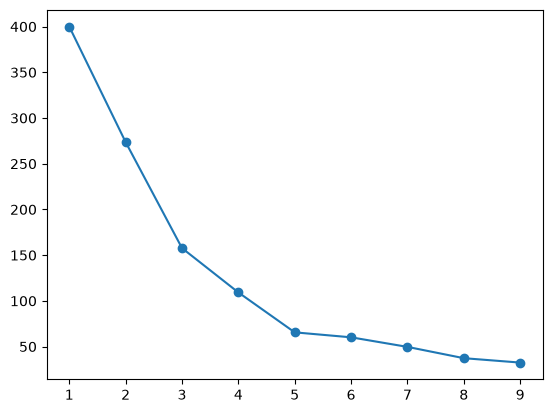

In [8]:
# 엘보우 기법으로 최적 k 찾기
result = []
for k in range(1,10) :
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans_temp.fit_predict(X_scaled)
    result.append(kmeans_temp.inertia_)

plt.plot(range(1,10), result, marker='o')

k 값 = 5 이후로 그래프의 기울기 변화가 미미해지는 것을 확인.
최적의 k는 5

In [ ]:
# 군집수 5의 KMeans 모델 정의 및 데이터 학습
kmeans = KMeans(
    n_clusters=5,
    n_init='auto',
    random_state=42
)

kmeans.fit(X_train)
train_labels = kmeans.labels_

test_labels = kmeans.predict(X_test)

In [ ]:
# 훈련 데이터와 테스트 데이터에 대한 실루엣 점수 평가
train_score = silhouette_score(X_train, train_labels)
test_score = silhouette_score(X_test, test_labels)

print(f'훈련 데이터의 실루엣 점수 : {train_score}')
print(f'테스트 데이터의 실루엣 점수 : {test_score}')

훈련 데이터의 실루엣 점수 : 0.5509842461121202
테스트 데이터의 실루엣 점수 : 0.566618490320996


훈련 데이터와 테스트 데이터의 실루엣 점수가 0.55~0.56 으로 유사한 점수이다. 군집 구조가 안정적으로 형성되었음을 알 수 있다.

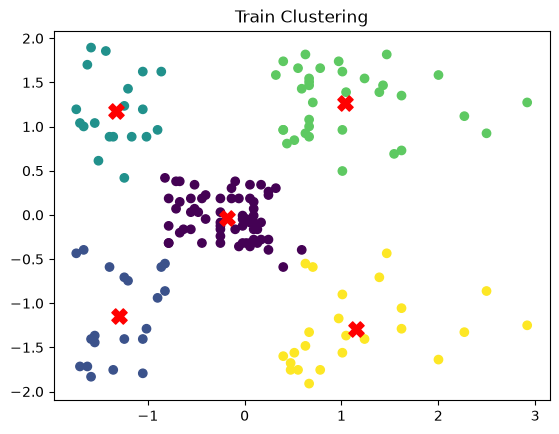

In [ ]:
# 군집의 중앙점 정의 및 훈련 데이터의 군집 산점도 그래프 시각화 및 평가
centers = kmeans.cluster_centers_

plt.scatter(X_train[:, 0], X_train[:, 1], c=train_labels, cmap='viridis')

plt.scatter(centers[:, 0], centers[:, 1], c='red', s=120, marker='X')

plt.title('Train Clustering')
plt.show()

훈련 데이터에 대해 클러스터링(k=5)을 수행한 결과, 각 군집이 전반적으로 잘 분리된 형태를 보인다. 일부는 경계가 모호하게 나타나지만 대부분은 명확하게 구분되었다. 앞서 실루엣 점수가 0.55 정도로 나타난 것을 생각하면 적합한 결과인 것 같다.

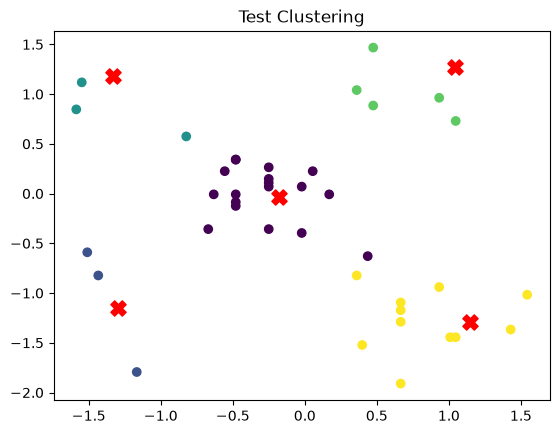

In [ ]:
# 테스트 데이터의 군집 산점도 그래프 시각화 및 평가
plt.scatter(X_test[:, 0], X_test[:, 1], c=test_labels, cmap='viridis')

plt.scatter(centers[:, 0], centers[:, 1], c='red', s=120, marker='X')

plt.title('Test Clustering')
plt.show()

테스트 데이터에 대해 클러스터링(k=5)을 수행한 결과, 각 군집이 전반적으로 잘 분리된 형태를 보인다. 하지만 데이터의 개수가 40개로 5개의 군집을 나누기에는 부족한 개수이다. 데이터의 개수가 대폭 증가된다면 명확한 군집의 모습을 볼 수 있을 것 같다.